In [83]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [84]:
import pandas as pd
print(pd.__version__)

3.0.3


In [85]:
import pandas as pd

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")
scheme_performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("Performance:", scheme_performance.shape)
print("Transactions:", transactions.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Performance: (40, 19)
Transactions: (32778, 13)


In [86]:
import os

for file in os.listdir("../data/raw"):
    print(file)

01_fund_master.csv
02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv
hdfc_live_nav.csv


In [87]:
import plotly.express as px

nav_history["date"] = pd.to_datetime(nav_history["date"])

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All 40 Schemes (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.15
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    annotation_text="2024 Correction",
    fillcolor="red",
    opacity=0.15
)

fig.show()

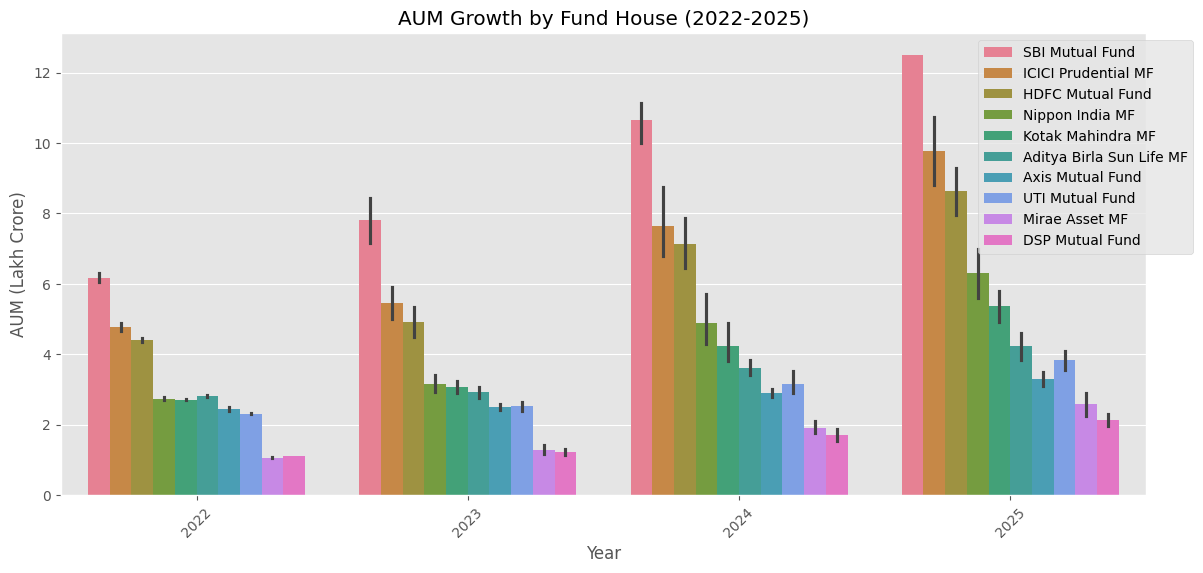

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.ylabel("AUM (Lakh Crore)")
plt.xlabel("Year")

plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))

plt.show()

# Key EDA Findings
1.SBI Mutual Fund has the highest AUM among all fund houses.
2.SIP inflows reached an all-time high of ₹31,002 Cr in Dec 2025.
3.Equity folios grew faster than debt folios.
4.Investors aged 26–35 form the largest investor segment.
5.Banking sector has the highest portfolio allocation.
6.NAV trends showed strong growth during 2023.
7.Most schemes exhibit positive return correlation.
8.B30 cities contribute significantly to SIP participation.
9.Male investors outnumber female investors.
10.Flexi Cap and Mid Cap categories attracted strong inflows.

In [90]:
import plotly.express as px

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr All-Time High",
    showarrow=True
)

fig.show()

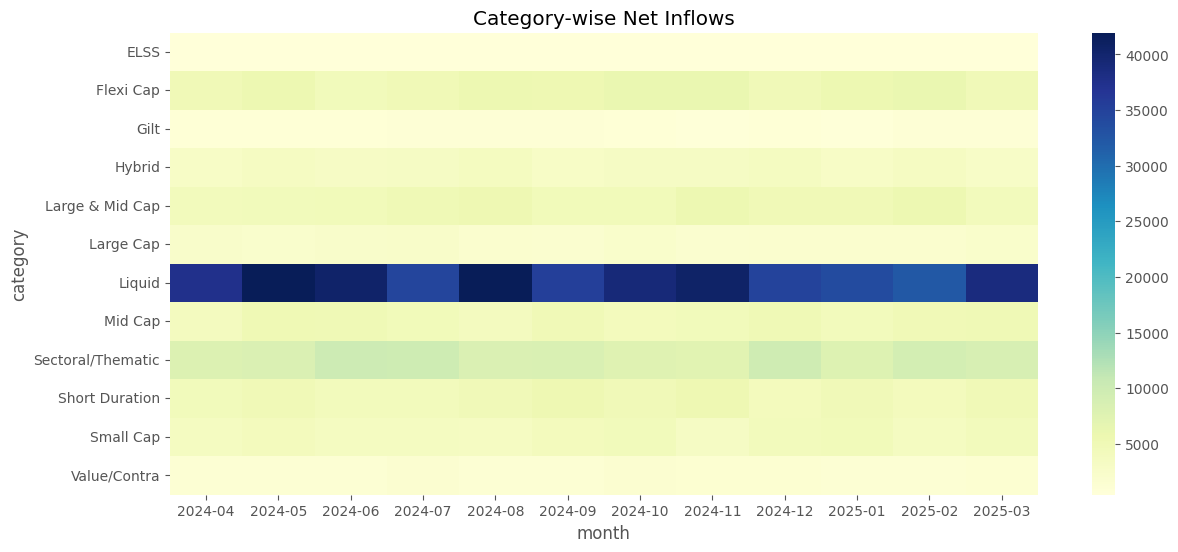

In [91]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

pivot_table = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot_table,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Net Inflows")

plt.show()

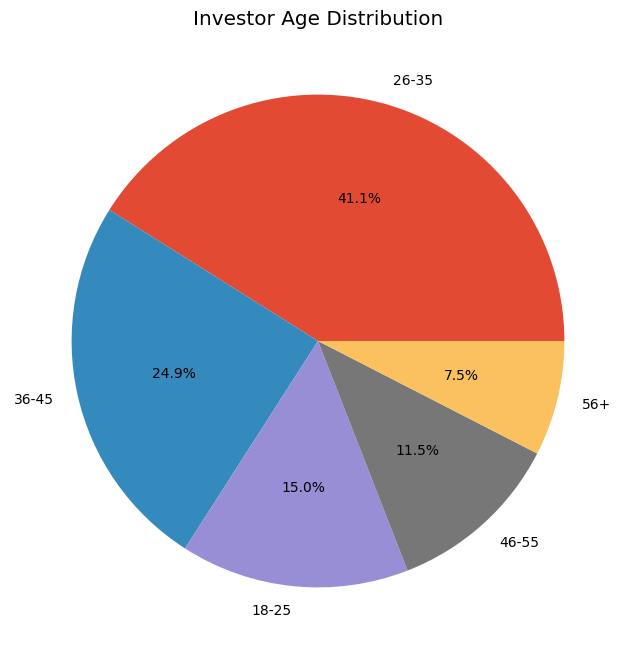

In [92]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")

plt.show()

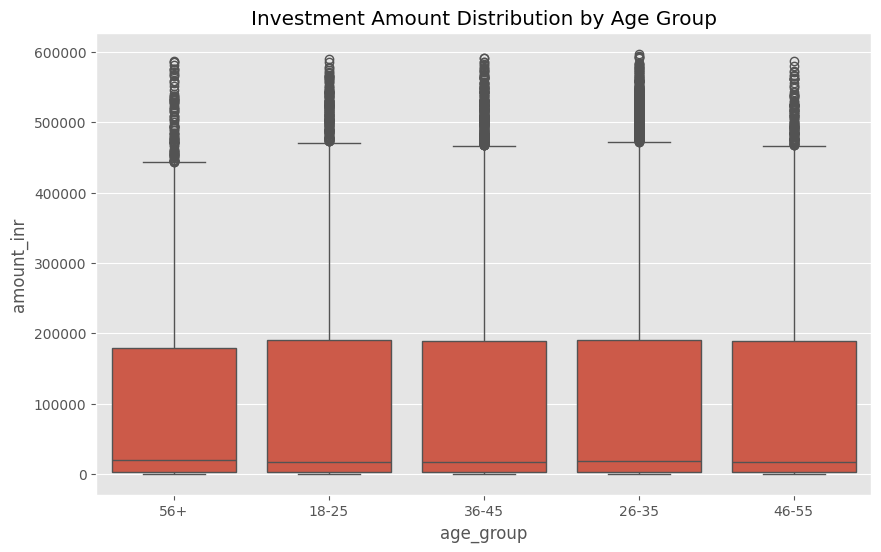

In [93]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")

plt.show()

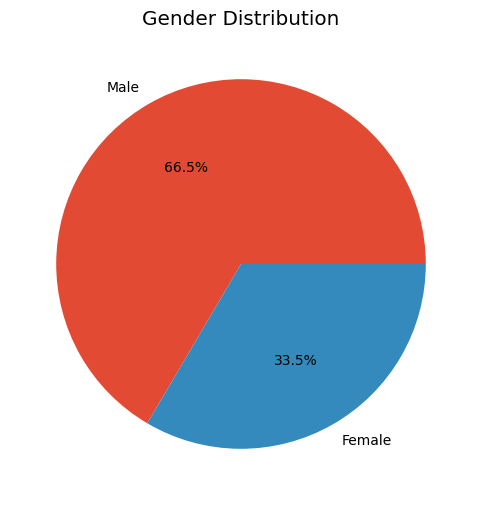

In [94]:
gender = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

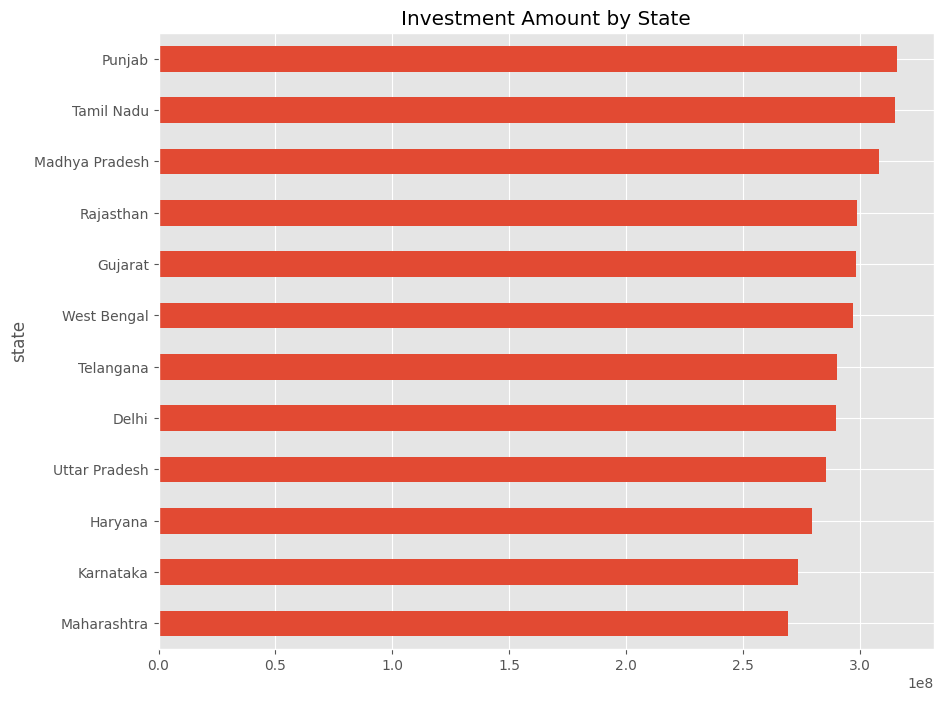

In [95]:
state_data = transactions.groupby("state")["amount_inr"].sum()

state_data = state_data.sort_values()

plt.figure(figsize=(10,8))

state_data.plot(kind="barh")

plt.title("Investment Amount by State")

plt.show()

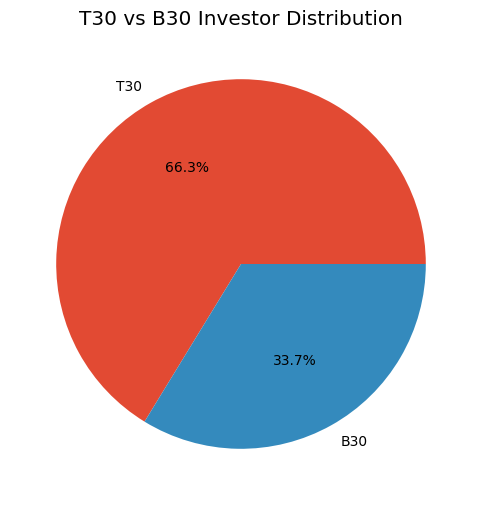

In [96]:
tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

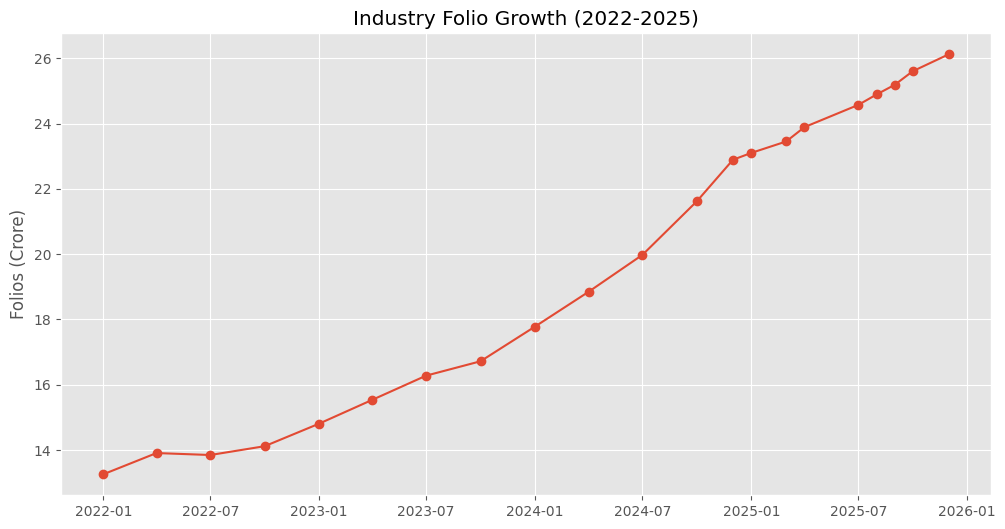

In [97]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth (2022-2025)")
plt.ylabel("Folios (Crore)")

plt.show()

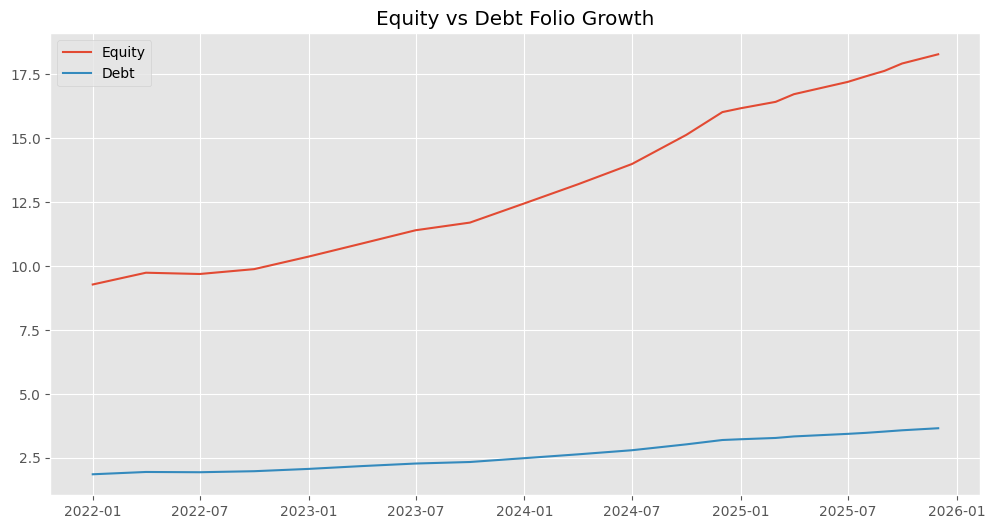

In [98]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["equity_folios_crore"],
    label="Equity"
)

plt.plot(
    folio["month"],
    folio["debt_folios_crore"],
    label="Debt"
)

plt.legend()

plt.title("Equity vs Debt Folio Growth")

plt.show()

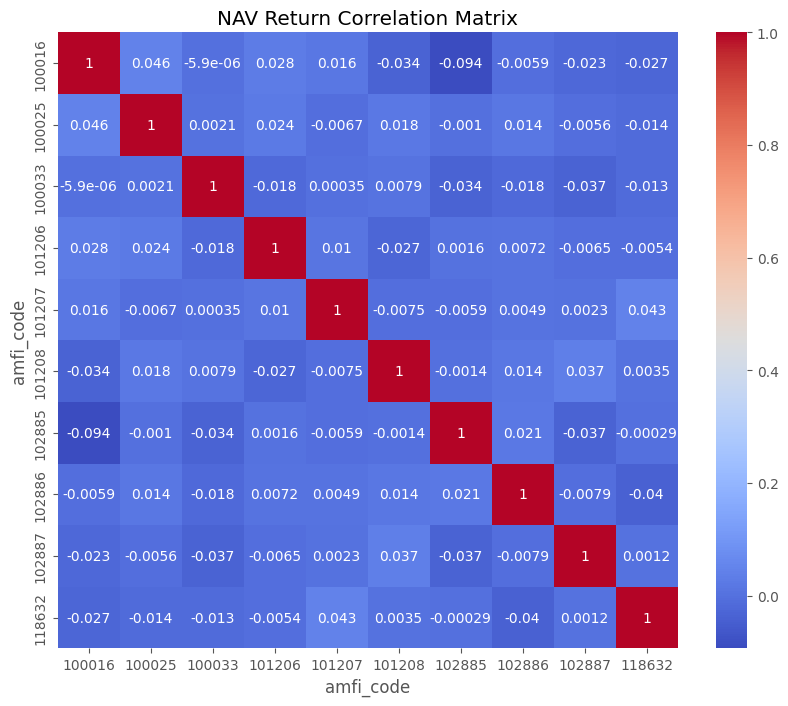

In [99]:
top10 = nav_history["amfi_code"].unique()[:10]

corr_data = nav_history[
    nav_history["amfi_code"].isin(top10)
]

pivot = corr_data.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)

plt.title("NAV Return Correlation Matrix")

plt.show()

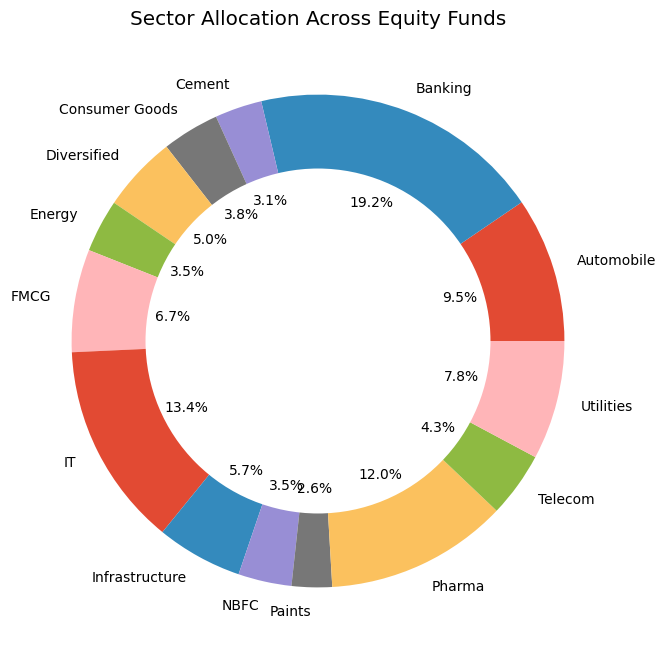

In [100]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

sector_data = holdings.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle((0,0),0.70,fc='white')

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

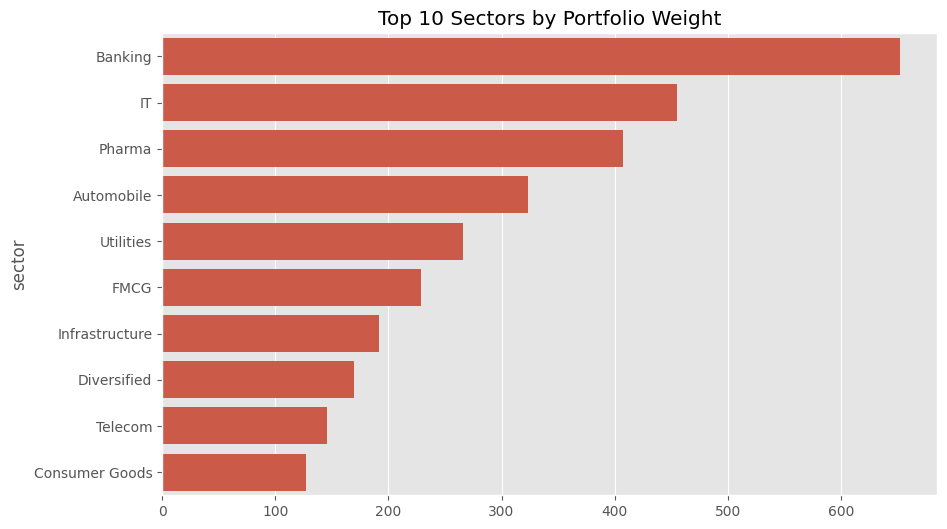

In [101]:
sector_top = holdings.groupby("sector")["weight_pct"].sum()

sector_top = sector_top.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=sector_top.values,
    y=sector_top.index
)

plt.title("Top 10 Sectors by Portfolio Weight")

plt.show()

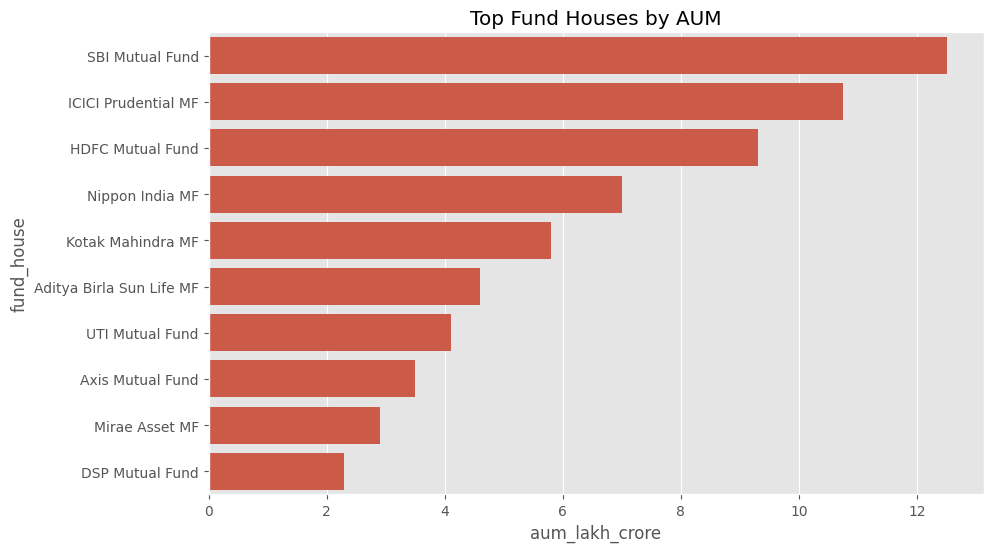

In [102]:
latest = aum.sort_values("date").groupby(
    "fund_house"
).tail(1)

latest = latest.sort_values(
    "aum_lakh_crore",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=latest,
    x="aum_lakh_crore",
    y="fund_house"
)

plt.title("Top Fund Houses by AUM")

plt.show()